<a href="https://colab.research.google.com/github/katezotko/Sales-Analytics/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data overview**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate_homework

# Uploading dataset
countries = pd.read_csv("countries.csv")
products = pd.read_csv("products.csv")
events = pd.read_csv("events.csv")
countries.head()

Mounted at /content/drive
/content/drive/MyDrive/Mate_homework


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


**name:** The full name of the country.

**alpha-2:** Two-letter ISO country code.

**alpha-3:** Three-letter ISO country code.

**region:** The macro-region the country belongs to.

**sub-region:** A more specific geographical division.

In [ ]:
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


**id:** A unique numerical identifier for the product category.

**item_type:** The descriptive name of the product category.

In [ ]:
events.columns = events.columns.str.lower()
events.head()

,order id,order date,ship date,order priority,country code,product id,sales channel,units sold,unit price,unit cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


**order id:** Unique identification number for each transaction.

**order date / ship date:** The dates when the order was placed and shipped.

**order priority:** The urgency level of the order (e.g., H, M, L, C).

**country code:** The three-letter code representing the destination country.

**product id:** The numerical code used to identify the type of product sold.

**sales channel:** Whether the sale was made "Online" or "Offline".

**units sold / unit price / unit cost:** Quantitative data regarding the volume and financial values of the sale.

The key fields for joining tables are **product id** (events) and **id** (products), as well as **country code** (events) and **alpha-3** (countries)

In [ ]:
countries.info()
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order id        1330 non-null   int64  
 1   order date      1330 non-null   object 
 2   ship date       1330 non-null   object 
 3   order priority  1330 non-null   object 
 4   country code    1248 non-null   object 
 5   product id      1330 non-null   int64  
 6   sales channel   1330 non-null   object 
 7   units sold      1328 non-null   float64
 8   unit price    


We have missing values ​​in both tables

In [ ]:
print(countries.dtypes)
print(events.dtypes)
print(products.dtypes)

name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object
order id            int64
order date         object
ship date          object
order priority     object
country code       object
product id          int64
sales channel      object
units sold        float64
unit price        float64
unit cost         float64
dtype: object
id            int64
item_type    object
dtype: object


The **order date** and **ship date** have incorrect value types. Must be datetime64[ns]. All other value types are correct.

# **Data cleaning**

In [ ]:
print(f"Number of missing values per column in events:\n{events.isna().sum()}")
print(f"Percentage of missing values in events:\n{events.isna().sum() / events.shape[0] * 100}")
print(f"Number of missing values per column in countries:\n{countries.isna().sum()}")
print(f"Percentage of missing values in events:\n{countries.isna().sum() / countries.shape[0] * 100}")

Number of missing values per column in events:
order id           0
order date         0
ship date          0
order priority     0
country code      82
product id         0
sales channel      0
units sold         2
unit price         0
unit cost          0
dtype: int64
Percentage of missing values in events:
order id          0.000000
order date        0.000000
ship date         0.000000
order priority    0.000000
country code      6.165414
product id        0.000000
sales channel     0.000000
units sold        0.150376
unit price        0.000000
unit cost         0.000000
dtype: float64
Number of missing values per column in countries:
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
Percentage of missing values in events:
name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In the events column **country code**, 6.17% of the values are missing. This may be due to a data collection error, missing information about the order location, or a technical failure. Since this represents a significant portion of the data, removing these rows could distort the dataset. Therefore, the missing values will be replaced with 'Unknown'.
In the **units sold** data, there are only two gaps, which are not critical for data analysis, so they can be removed.
The countries table has missing values in the **alpha-2, region** and **sub-region** columns, likely for a territory or island without assigned standard codes.

In [ ]:
events['country code'] = events['country code'].fillna('Unknown')
events = events.dropna(subset=['units sold'])
countries = countries.dropna(subset=['alpha-2', 'region', 'sub-region'])
print(f"Number of missing values per column in events:\n{events.isna().sum()}")
print(f"Number of missing values per column in countries:\n{countries.isna().sum()}")

Number of missing values per column in events:
order id          0
order date        0
ship date         0
order priority    0
country code      0
product id        0
sales channel     0
units sold        0
unit price        0
unit cost         0
dtype: int64
Number of missing values per column in countries:
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64


In [ ]:
events_duplicates = events.duplicated()
print(events_duplicates.sum())

countries_duplicates = countries.duplicated()
print(countries_duplicates.sum())

if not countries_duplicates.any():
    print("No duplicates found")

0
0
No duplicates found


In [ ]:

events['order date'] = pd.to_datetime(events['order date'], errors='coerce')
events['ship date'] = pd.to_datetime(events['ship date'], errors='coerce')
print(events.dtypes[['order date']])
print(events.dtypes[['ship date']])

order date    datetime64[ns]
dtype: object
ship date    datetime64[ns]
dtype: object


In [ ]:
print(events[['order date', 'ship date']].isna().sum())
anomalies = events[events['ship date'] < events['order date']]
print(f"Count of anomalous dates: {len(anomalies)}")

order date    0
ship date     0
dtype: int64
Count of anomalous dates: 0


In [ ]:
price_anomaly = events[(events['unit price'] <= 0) | (events['unit cost'] <= 0)]
loss_events = events[events['unit price'] < events['unit cost']]
print(f"Sales at a loss: {len(loss_events)}")

Sales at a loss: 0


In [ ]:
countries.describe()

,name,alpha-2,alpha-3,region,sub-region
count,247,247,247,247,247
unique,247,247,247,5,17
top,Afghanistan,AF,AFG,Africa,Latin America and the Caribbean
freq,1,1,1,59,52


In [ ]:
events.describe()

,order id,order date,ship date,product id,units sold,unit price,unit cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


Based on the descriptive statistics, no anomalies were detected. The data is clean and logically consistent: the count of anomalous dates is 0, and the financial metrics check revealed no instances of sales at a loss.

# **Data analysis and visualization**

In [ ]:
df_merged = events.merge(products, left_on='product id', right_on='id', how='left')
df_final = df_merged.merge(countries, left_on='country code', right_on='alpha-3', how='left')


df_final = df_final.rename(columns={
    'name': 'country',
    'item_type': 'product category'
})

cols_to_drop = ['id', 'alpha-3', 'alpha-2']
df_final = df_final.drop(columns=cols_to_drop)

df_final['country'] = df_final['country'].fillna('Unknown')

df_final.head()

,order id,order date,ship date,order priority,country code,product id,sales channel,units sold,unit price,unit cost,product category,country,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,Unknown,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


**Key Metrics**

In [ ]:
total_orders = df_final['order id'].nunique()

total_units_sold = df_final['units sold'].sum()

df_final['total profit'] = (df_final['unit price'] - df_final['unit cost']) * df_final['units sold']
total_profit = df_final['total profit'].sum()

total_countries = df_final['country'].nunique()

aov = (df_final['unit price'] * df_final['units sold']).sum() / total_orders

average_margin = ((df_final['unit price'] - df_final['unit cost']) / df_final['unit price']).mean() * 100

print(f"Key Performance Indicators:")
print(f"---")
print(f"Total Orders: {total_orders}")
print(f"Total Units Sold: {total_units_sold:,.0f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Countries Covered: {total_countries}")
print(f"Average Order Value: ${aov:,.2f}")
print(f"Average Margin: {average_margin:.2f}%")

Key Performance Indicators:
---
Total Orders: 1328
Total Units Sold: 6,576,524
Total Profit: $501,434,459.00
Countries Covered: 46
Average Order Value: $1,281,723.95
Average Margin: 34.10%


**Analyze sales by product category, geography, and sales channels**

In [ ]:
df_final['total revenue'] = df_final['unit price'] * df_final['units sold']
df_final['total cost'] = df_final['unit cost'] * df_final['units sold']
df_final['total profit'] = df_final['total revenue'] - df_final['total cost']

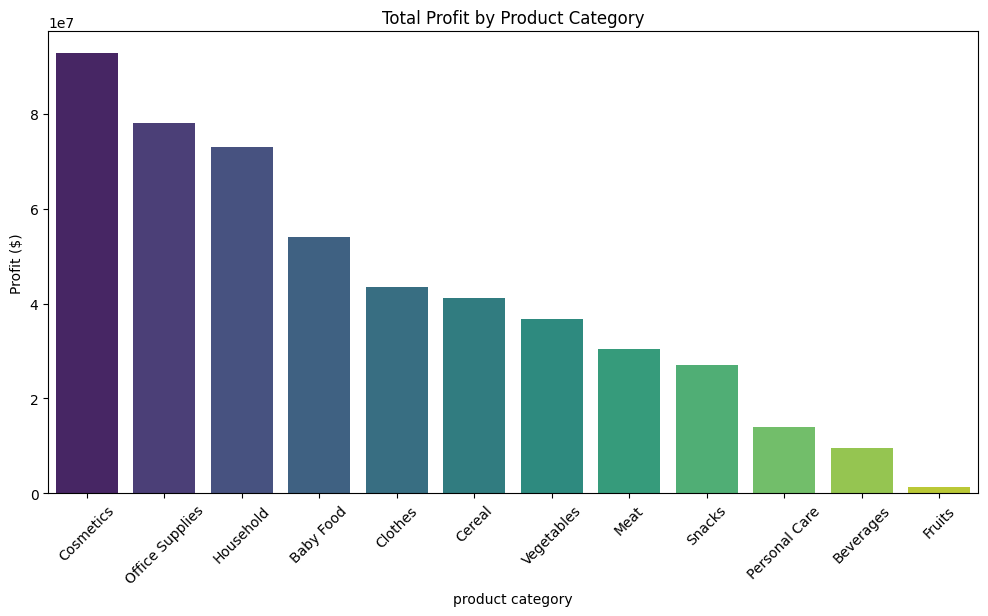

In [ ]:
category_analysis = df_final.groupby('product category').agg({'total profit': 'sum','units sold': 'sum'}).sort_values(by='total profit', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_analysis.index, y=category_analysis['total profit'], hue=category_analysis.index, palette='viridis', legend=False)
plt.title('Total Profit by Product Category')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45)
plt.show()

**1. Dominant Categories**
The analysis reveals that **Cosmetics** is the most profitable category, significantly outperforming all other groups. It is followed by **Vegetables** and **Household items**, which serve as the primary drivers of the company's bottom line.

**2. Mid-Tier Performance**
Categories such as **Baby Food, Meat** and **Cereal** show moderate profitability. While they contribute steadily to the total revenue, there is a noticeable gap between these mid-tier products and the top three performers.

**3. Underperforming Categories**
**Personal Care, Beverages** and **Snacks** are currently at the lower end of the profit spectrum. The least profitable category is **Fruits**, which generates the smallest margin among all analyzed product types.

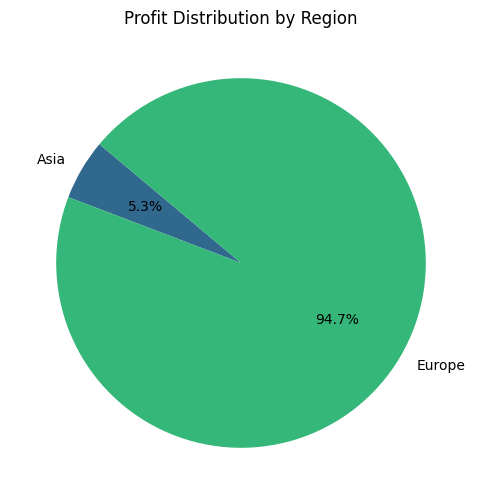

In [ ]:
region_analysis = df_final.groupby('region')['total profit'].sum().sort_values()
colors = sns.color_palette('viridis', len(region_analysis))

plt.figure(figsize=(6, 6))
plt.pie(region_analysis, labels=region_analysis.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Profit Distribution by Region')
plt.show()

The **European** market is the primary driver of the company's profitability, accounting for a  94.7% of the total profit.

**Asia** represents a very small fraction of the total profit distribution, contributing only 5.3%. The low percentage in Asia suggests either a very recent market entry or significant challenges in scaling operations within that region.

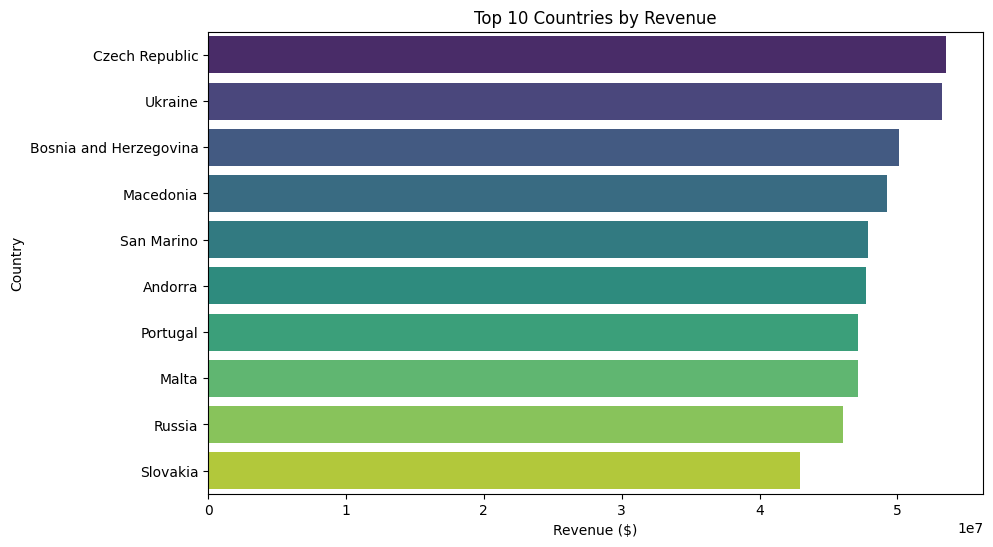

In [ ]:
df_filtered = df_final[(df_final['country'] != 'Unknown') & (df_final['country'].notna())]
top_countries = df_filtered.groupby('country')['total revenue'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Country')
plt.show()

Regional Leadership: The **Czech Republic** and **Ukraine** are the absolute leaders in terms of revenue. A significant share of overall sales is concentrated in Eastern Europe and the Balkans (notably **Bosnia and Herzegovina** and **North Macedonia**), which confirms a successful localization strategy in these regions.

High-Efficiency Markets: We observe exceptionally high efficiency in smaller nations like **San Marino** and **Andorra**. These countries demonstrate high revenue per customer, identifying them as valuable, high-margin niche markets.


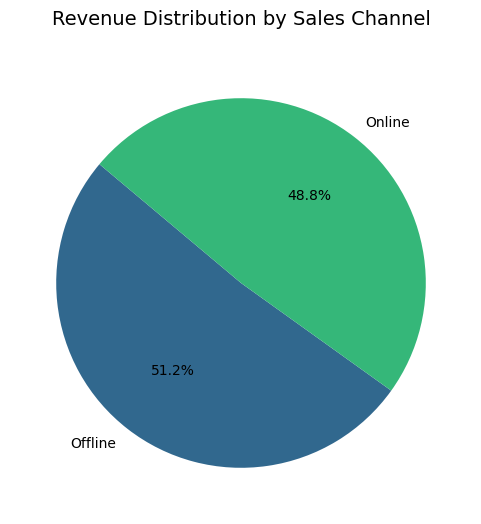

In [ ]:
df_final['sales channel'] = df_final['sales channel'].str.strip().str.capitalize()
channel_data = df_final.groupby('sales channel')['total revenue'].sum()
colors = sns.color_palette('viridis', len(region_analysis))
plt.figure(figsize=(6, 6))
plt.pie(channel_data, labels=channel_data.index, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('Revenue Distribution by Sales Channel', fontsize=14, pad=20)
plt.show()

An almost even distribution of revenue is observed between the two primary channels:
*   Offline: 51.2%
*   Online: 48.8%

The marginal difference of only 2.4% indicates a highly balanced business model.

The 48.8% share for **Online** sales is notably high, suggesting that
the platform is highly user-friendly and accessible, consumer trust in digital payments is established and marketing investments in digital channels are yielding a strong return on spend.

Despite this, the **Offline** channel still accounts for the majority of revenue (51.2%). This is driven by specific consumer behavior patterns, including demographic characteristics and the customer's need for a sensory experience (physical interaction with the product) and face-to-face consultations before finalizing a purchase.

**Order lead time analysis by product category, countries, and region**


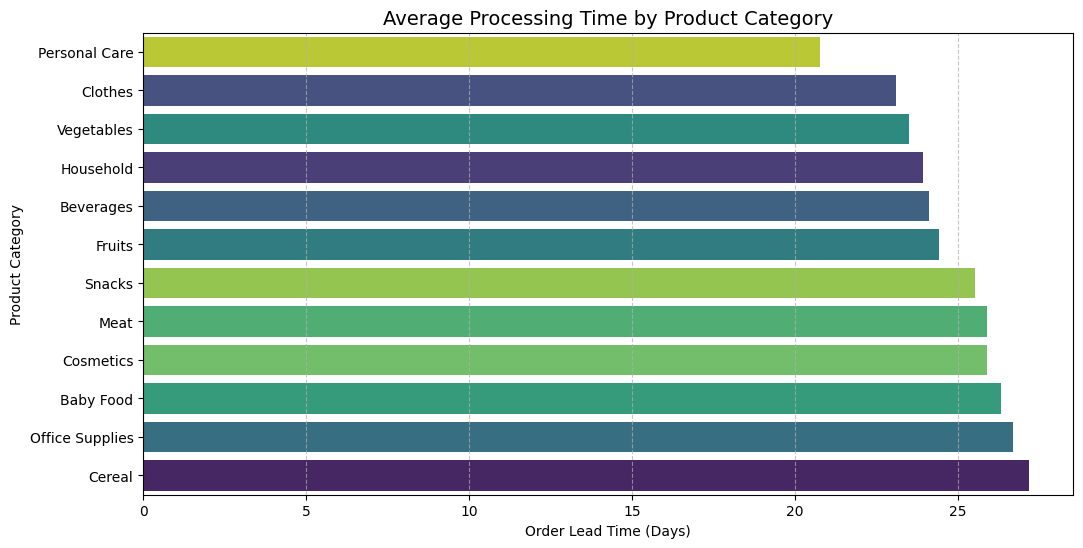

In [ ]:
df_final['days_to_ship'] = (df_final['ship date'] - df_final['order date']).dt.days
plt.style.use('seaborn-v0_8-muted')
sns.set_palette("viridis")
plt.figure(figsize=(12, 6))
category_order =  df_final.groupby('product category')['days_to_ship'].mean().sort_values().index
sns.barplot(x='days_to_ship', y='product category', data=df_final, errorbar=None, order=category_order, hue='product category', palette='viridis', legend=False)
plt.title('Average Processing Time by Product Category', fontsize=14)
plt.xlabel('Order Lead Time (Days)')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

The average processing time across all categories ranges from 21 to 27 days, which is a relatively long interval for the fulfillment stage. Potential reasons for this include:

* The complexity of international logistics or multi-tier supply chains.

* The production cycle (particularly for made-to-order products).

* A lack of prioritization protocols between different product types.

**Personal Care** is the leader in processing speed with the shortest interval of approximately 21 days. As a high-turnover category of everyday essentials, this efficiency is expected.

**Clothing** and **Vegetables** perform better than the average, with processing times of 23–24 days. For Vegetables, this speed is logical given their limited shelf life.

**Cereal** and **Office Supplies** exhibit the longest lead times, averaging 26–27 days.

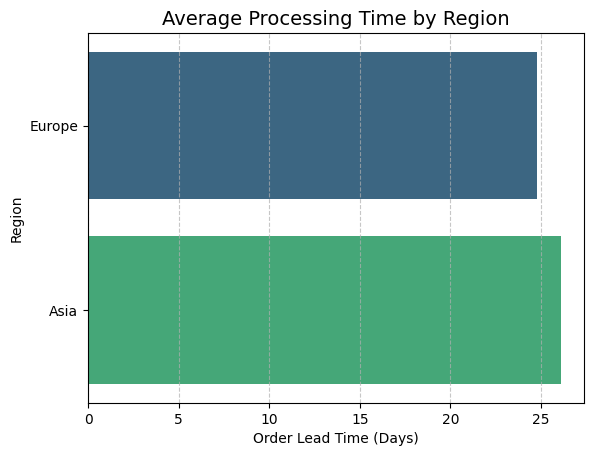

In [ ]:
region_order = df_final.groupby('region')['days_to_ship'].mean().sort_values().index
sns.barplot(x='days_to_ship', y='region', data=df_final, errorbar=None, order=region_order, palette='viridis',hue='region', legend=False)
plt.title('Average Processing Time by Region', fontsize=14)
plt.xlabel('Order Lead Time (Days)')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Europe** demonstrates a higher processing speed, averaging 24–25 days. Since the majority of top-performing countries by revenue are located in this region, the company has maintained a strategic focus on developing a robust warehouse infrastructure there.

In **Asia**, performance is slightly lower, with an average lead time of 26–27 days. The marginal difference of only two days compared to Europe is a positive signal. This suggests that logistics processes in Asia are established almost as efficiently as those in the European market.

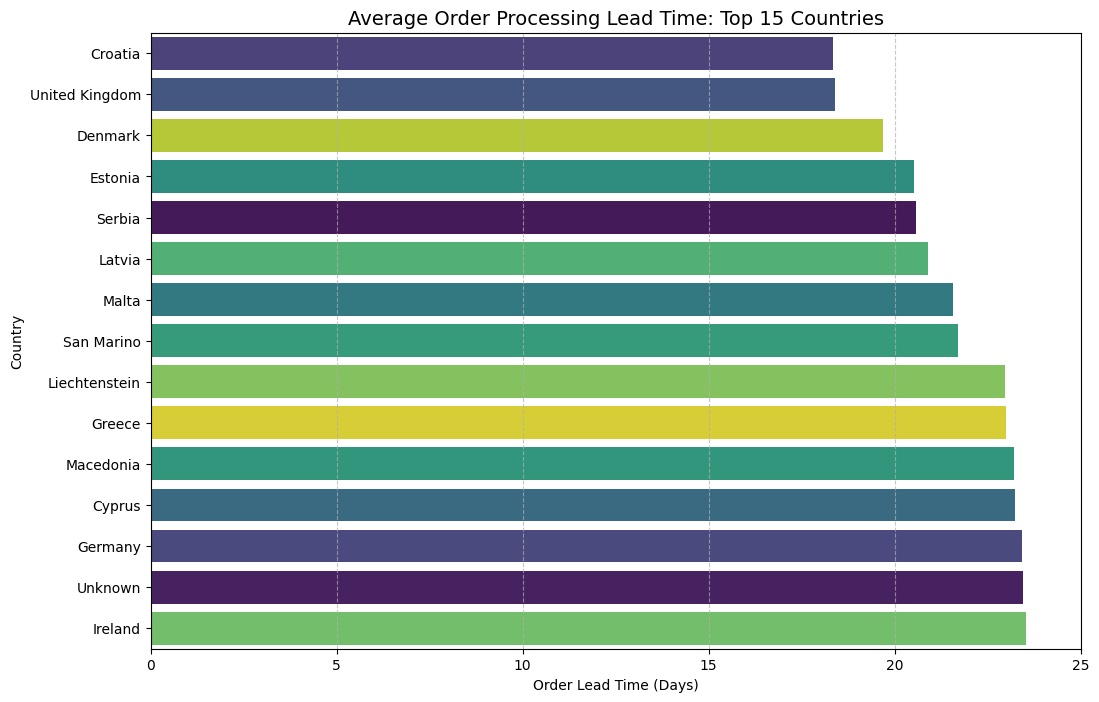

In [ ]:
top_countries_list = df_final.groupby('country')['days_to_ship'].mean().nsmallest(15).index
plt.figure(figsize=(12, 8))
plt.xlim(0, 25)
sns.barplot(x='days_to_ship', y='country', data=df_final, errorbar=None, order=top_countries_list, palette='viridis', hue='country', legend=False)
plt.title('Average Order Processing Lead Time: Top 15 Countries', fontsize=14)
plt.xlabel('Order Lead Time (Days)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Croatia** and the **United Kingdom** are the leaders in delivery speed. The average order processing time is about 18-19 days.

The difference between the 1st and 15th place is minimal, from 18 to 24 days. This indicates that in these countries the logistics processes are already quite well optimized and work according to similar standards.

Also on the list are many small countries and island states: **Malta, Cyprus, Iceland, San Marino, Liechtenstein**. may indicate that the small market size in these countries allows orders to be processed faster. It is easier for companies to manage small local warehouses or direct deliveries to a limited number of customers.

**Analysis of the dependence of profit on order execution time**

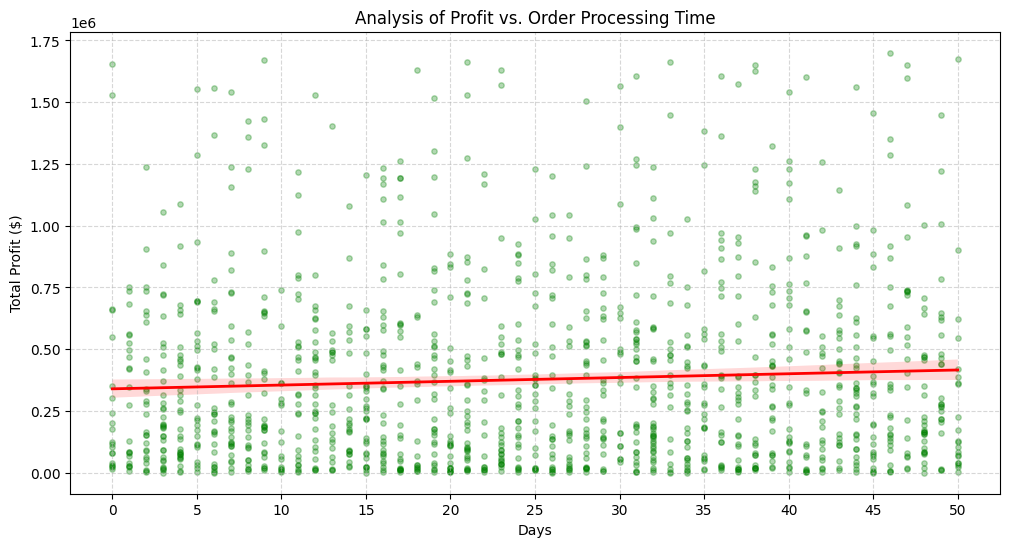

In [ ]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df_final, x='days_to_ship', y='total profit', scatter_kws={'s': 15, 'alpha': 0.3, 'color': 'green'}, line_kws={'color': 'red', 'lw': 2})

plt.title('Analysis of Profit vs. Order Processing Time')
plt.xlabel('Days')
plt.ylabel('Total Profit ($)')
plt.xticks(range(0, int(df_final['days_to_ship'].max()) + 5, 5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The analysis revealed a weak positive correlation between order processing time and total profit per order.

As processing time increases from 0 to 50 days, the regression line shows a slight upward trend in profitability. This partially suggests that higher-margin orders can be more complex and require a longer operational cycle. The current logistics model effectively handles large or high-value orders despite their extended preparation time, maintaining solid margins.

However, the high variance across all days indicates that short-cycle orders (0 - 10 days) can also yield maximum profits, and processing time alone is not the primary driver of order profitability.

**Sales Dynamics Over Time by Product Category, Country, and Region**

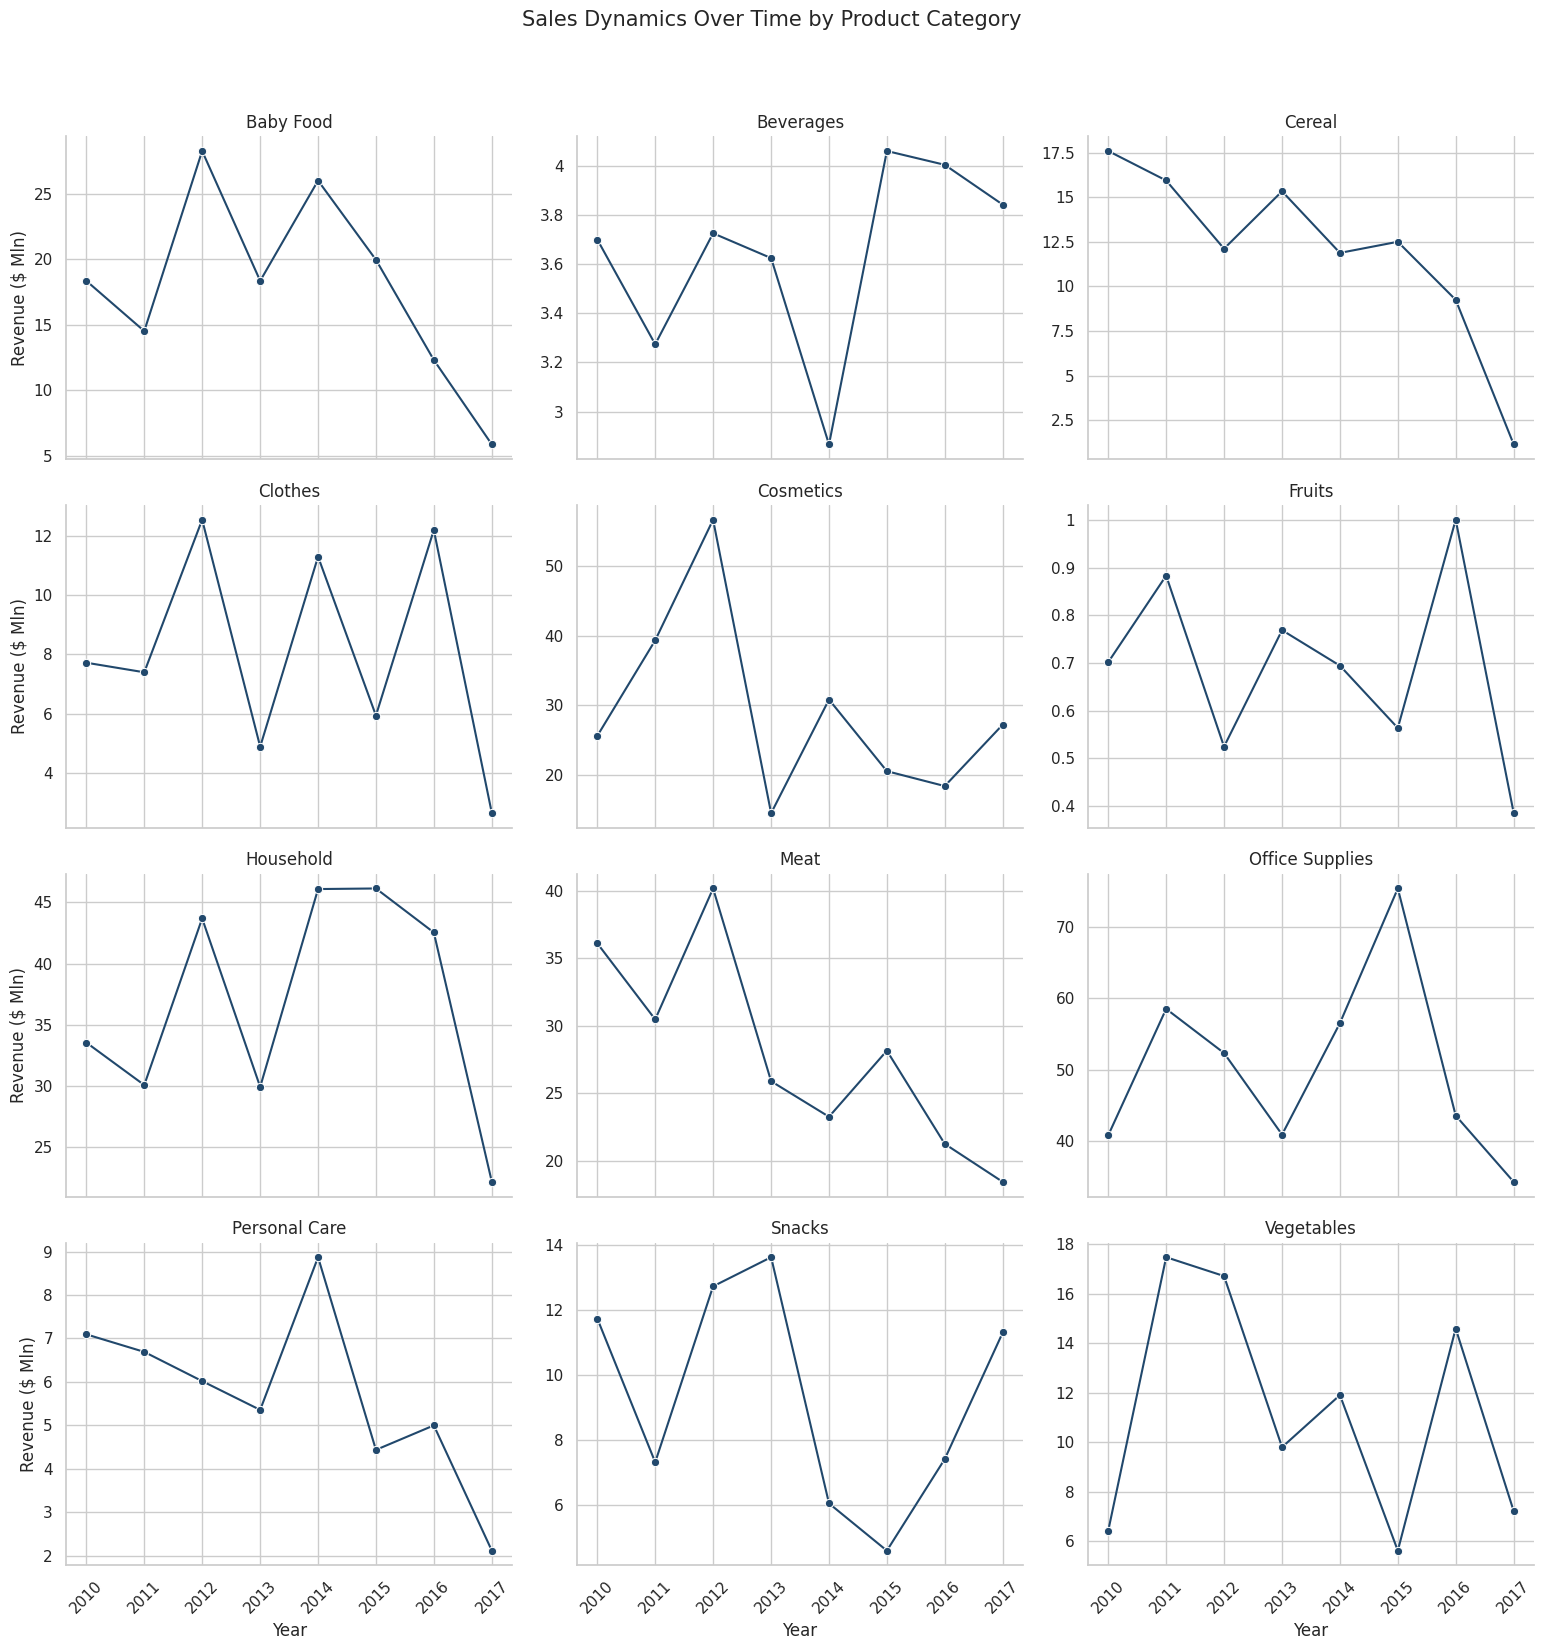

In [ ]:
import matplotlib.ticker as ticker
df_final["order year"] = (df_final["order date"].dt.to_period("Y").dt.to_timestamp())
category_trend = (df_final.groupby(["order year", "product category"])["total revenue"].sum().reset_index())

category_trend["revenue mln"] = category_trend["total revenue"] / 1_000_000

sns.set_theme(style="whitegrid")

g = sns.relplot(data=category_trend,x="order year", y="revenue mln", col="product category", col_wrap=3, kind="line", marker="o", color="#21486c", height=4, aspect=1.3, facet_kws={"sharey": False})

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Revenue ($ Mln)")

for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=45)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%g"))

g.fig.suptitle("Sales Dynamics Over Time by Product Category", fontsize=15, y=1.03)

plt.tight_layout()
plt.show()

**1. High-Revenue Categories**

These categories form the company's main financial flow, with their annual revenue measured in tens of millions of dollars.

**Office Supplies:** The absolute leader in terms of volume. It shows wave-like dynamics with a colossal peak in 2015 (over \$75 million). After that, the trend rapidly declined, returning to a low of ~\$34 million in 2017.

**Cosmetics:** A category that grew rapidly from 2010 to 2012, reaching a peak of ~\$56 million. In 2013, a sharp drop was recorded (to \$15 million), after which the category began to gradually recover, stabilizing in the \$20 - 27 million range.

**Household:** Demonstrates high volatility with two strong peaks in 2012 and 2014 - 2015 (at \$44 - 46 million). In 2017, the trend collapsed to a historic low of \$22 million.

**Meat:** The only major category that shows a stable downward macro trend. Starting from a peak of \$40 million in 2012, revenue has been declining annually, except for a small recovery in 2015, falling below \$20 million in 2017.

**2. Mid-Revenue Categories**

Segments with a stable annual turnover in the range of \$5 - 25 million.

**Baby Food:** Had strong peaks in 2012 and 2014 (\$26 - 28 million). However, since 2015, the category has been in a state of deep stagnation and decline, ending 2017 at just \$6 million.

Cereal: Shows a steady, long-term decline. While in 2010 the category brought in over \$17.5 million, by 2017 its volume had decreased to \$1.5 million.

Vegetables, Snacks, Clothes: Exhibit very similar cyclical "up and down" fluctuations every 1 - 2 years. Peak values for Vegetables and Clothes reach \$12 - 17 million, while Snacks peak at about \$14 million. All three categories synchronously sank in 2017.

**3. Low-Revenue Categories**

Categories that have the least impact on the overall cash flow.

**Personal Care:** The total volume fluctuates within the \$2 - 9 million range. The category saw local success in 2014 (\$9 million), but the global trend remains downward.

**Beverages:** A very specific, stable trend. The figures are squeezed into a narrow corridor between \$2.8 million and \$4.1 million. Unlike other segments, this category showed growth in 2015 - 2016 and barely declined in 2017.

**Fruits:** The smallest segment of the company. Annual revenue never exceeds \$1 million, showing a sharp sawtooth pattern with alternating successful and unsuccessful years.

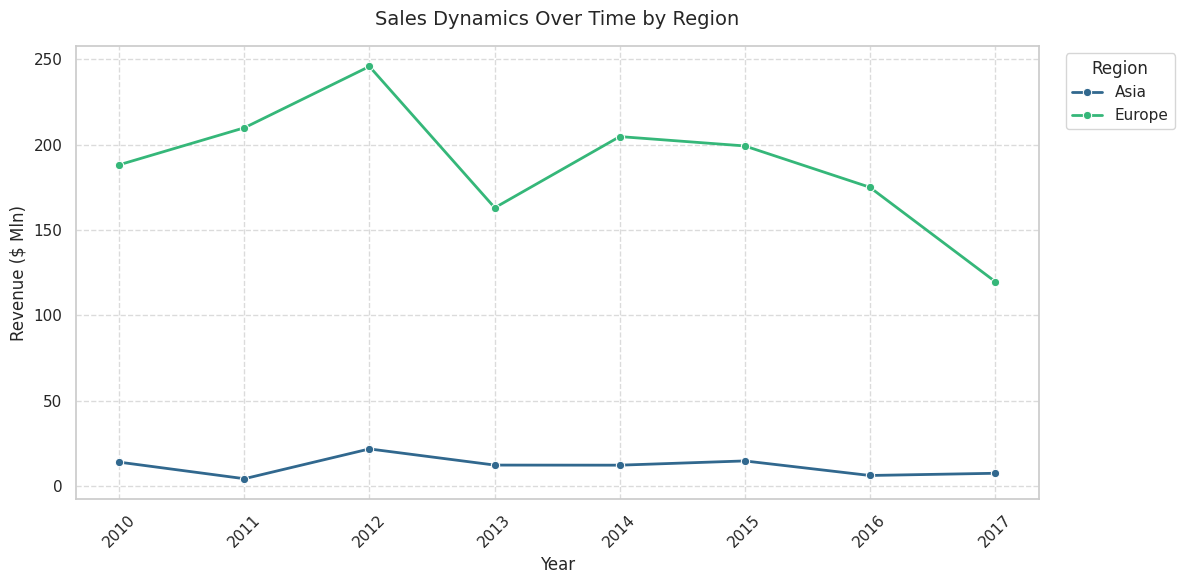

In [ ]:
region_trend = (df_final.groupby(["order year", "region"])["total revenue"].sum().reset_index())
region_trend["revenue_mln"] = region_trend["total revenue"] / 1_000_000

plt.figure(figsize=(12, 6))
sns.lineplot(data=region_trend, x="order year", y="revenue_mln", hue="region", palette="viridis", marker="o",linewidth=2,)

plt.title("Sales Dynamics Over Time by Region", fontsize=14, pad=15)
plt.xlabel("Year")
plt.ylabel("Revenue ($ Mln)")

plt.grid(axis="both", linestyle="--", alpha=0.7)

plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%g"))

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Region")

plt.tight_layout()
plt.show()

**Europe** is the company’s main source of revenue, with sales measured in hundreds of millions of dollars.

2010 - 2012: Beginning at ~\$190 million in 2010, the market showed rapid growth and reached its all-time high in 2012 (nearly \$250 million).

2013 - 2014: In 2013, revenue fell sharply to \$160 million, after which the market partially recovered in 2014, returning to just above \$200 million.

2015 - 2017: Since 2015, revenue has been on a steady decline, reaching its absolute minimum of approximately \$120 million in 2017.

The **Asian** region plays a relatively small role in the company’s overall financial flow, with revenue fluctuating between \$5 million and \$22 million.
The graph shows relative stability with a slight increase in 2012, peaking at \$22 million.
Unlike Europe, which fell sharply from 2015 to 2017, the Asian market remained stable during the same period, staying within the \$7 - 10 million range. It barely reacted to the overall decline of 2017.

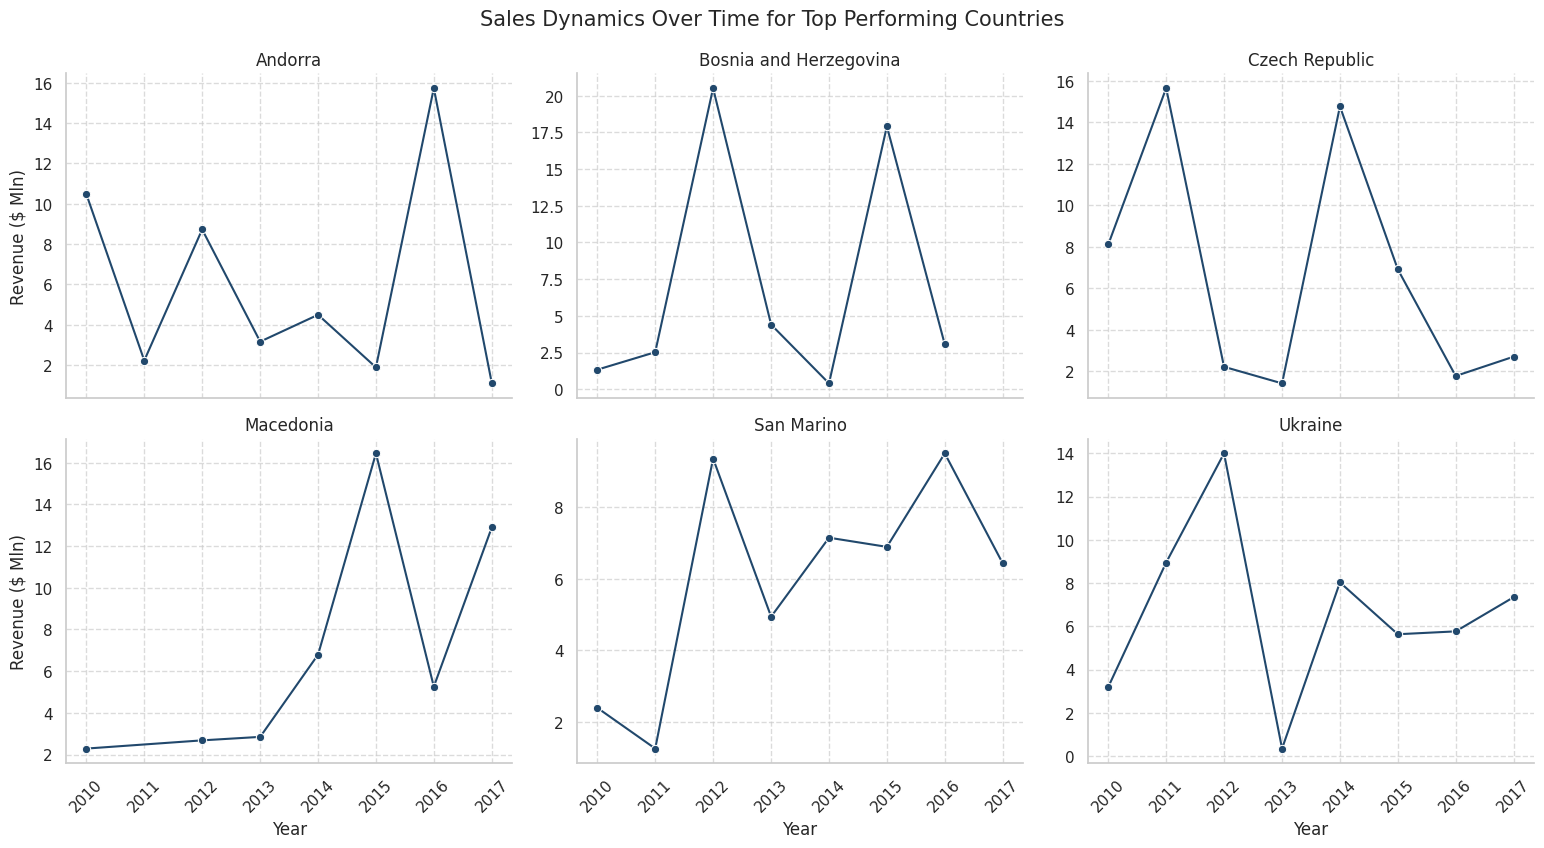

In [ ]:
df_clean_country = df_final[df_final["country"].notna() & (df_final["country"].astype(str).str.lower() != "unknown")]

top_countries_list = (df_clean_country.groupby("country")["total revenue"].sum().nlargest(6).index)
df_top_countries = df_clean_country[df_clean_country["country"].isin(top_countries_list)]

country_trend = (df_top_countries.groupby(["order year", "country"])["total revenue"].sum().reset_index())
country_trend["revenue_mln"] = country_trend["total revenue"] / 1_000_000

g = sns.relplot(data=country_trend, x="order year", y="revenue_mln", col="country", col_wrap=3, kind="line", marker="o", color="#21486c", height=4, aspect=1.3, facet_kws={"sharey": False})

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Revenue ($ Mln)")

for ax in g.axes.flat:
    ax.grid(axis="both", linestyle="--", alpha=0.7)
    ax.tick_params(axis="x", labelrotation=45)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%g"))

g.fig.suptitle("Sales Dynamics Over Time for Top Performing Countries", fontsize=15, y=1.03)

plt.show()

Country-level visualization strongly confirms the transactional volatility hypothesis. Instead of continuous retail sales, performance indicators in leading countries such as **Bosnia and Herzegovina, Andorra, and Ukraine** are characterized by massive spikes reaching \$14 - 20+ million, separated by sharp market corrections and steep post-peak drops.

**Macedonia** stands out as a market demonstrating a powerful, albeit volatile, long-term growth trend: after remaining flat at around \$2 million between 2010 and 2013, it surged to an all-time high of nearly \$16.5 million in 2015 and closed 2017 at a strong \$13 million.

Stable horizontal segments on the charts, such as **Ukraine’s** performance throughout 2015 - 2016, indicate periods where annual volumes temporarily stabilized. This cyclical, "sawtooth" pattern across almost all subplots proves that supply chain operations heavily rely on sporadic wholesale fulfillment rather than smooth, predictable consumer demand.

**Revenue Analysis by Day of the Week**

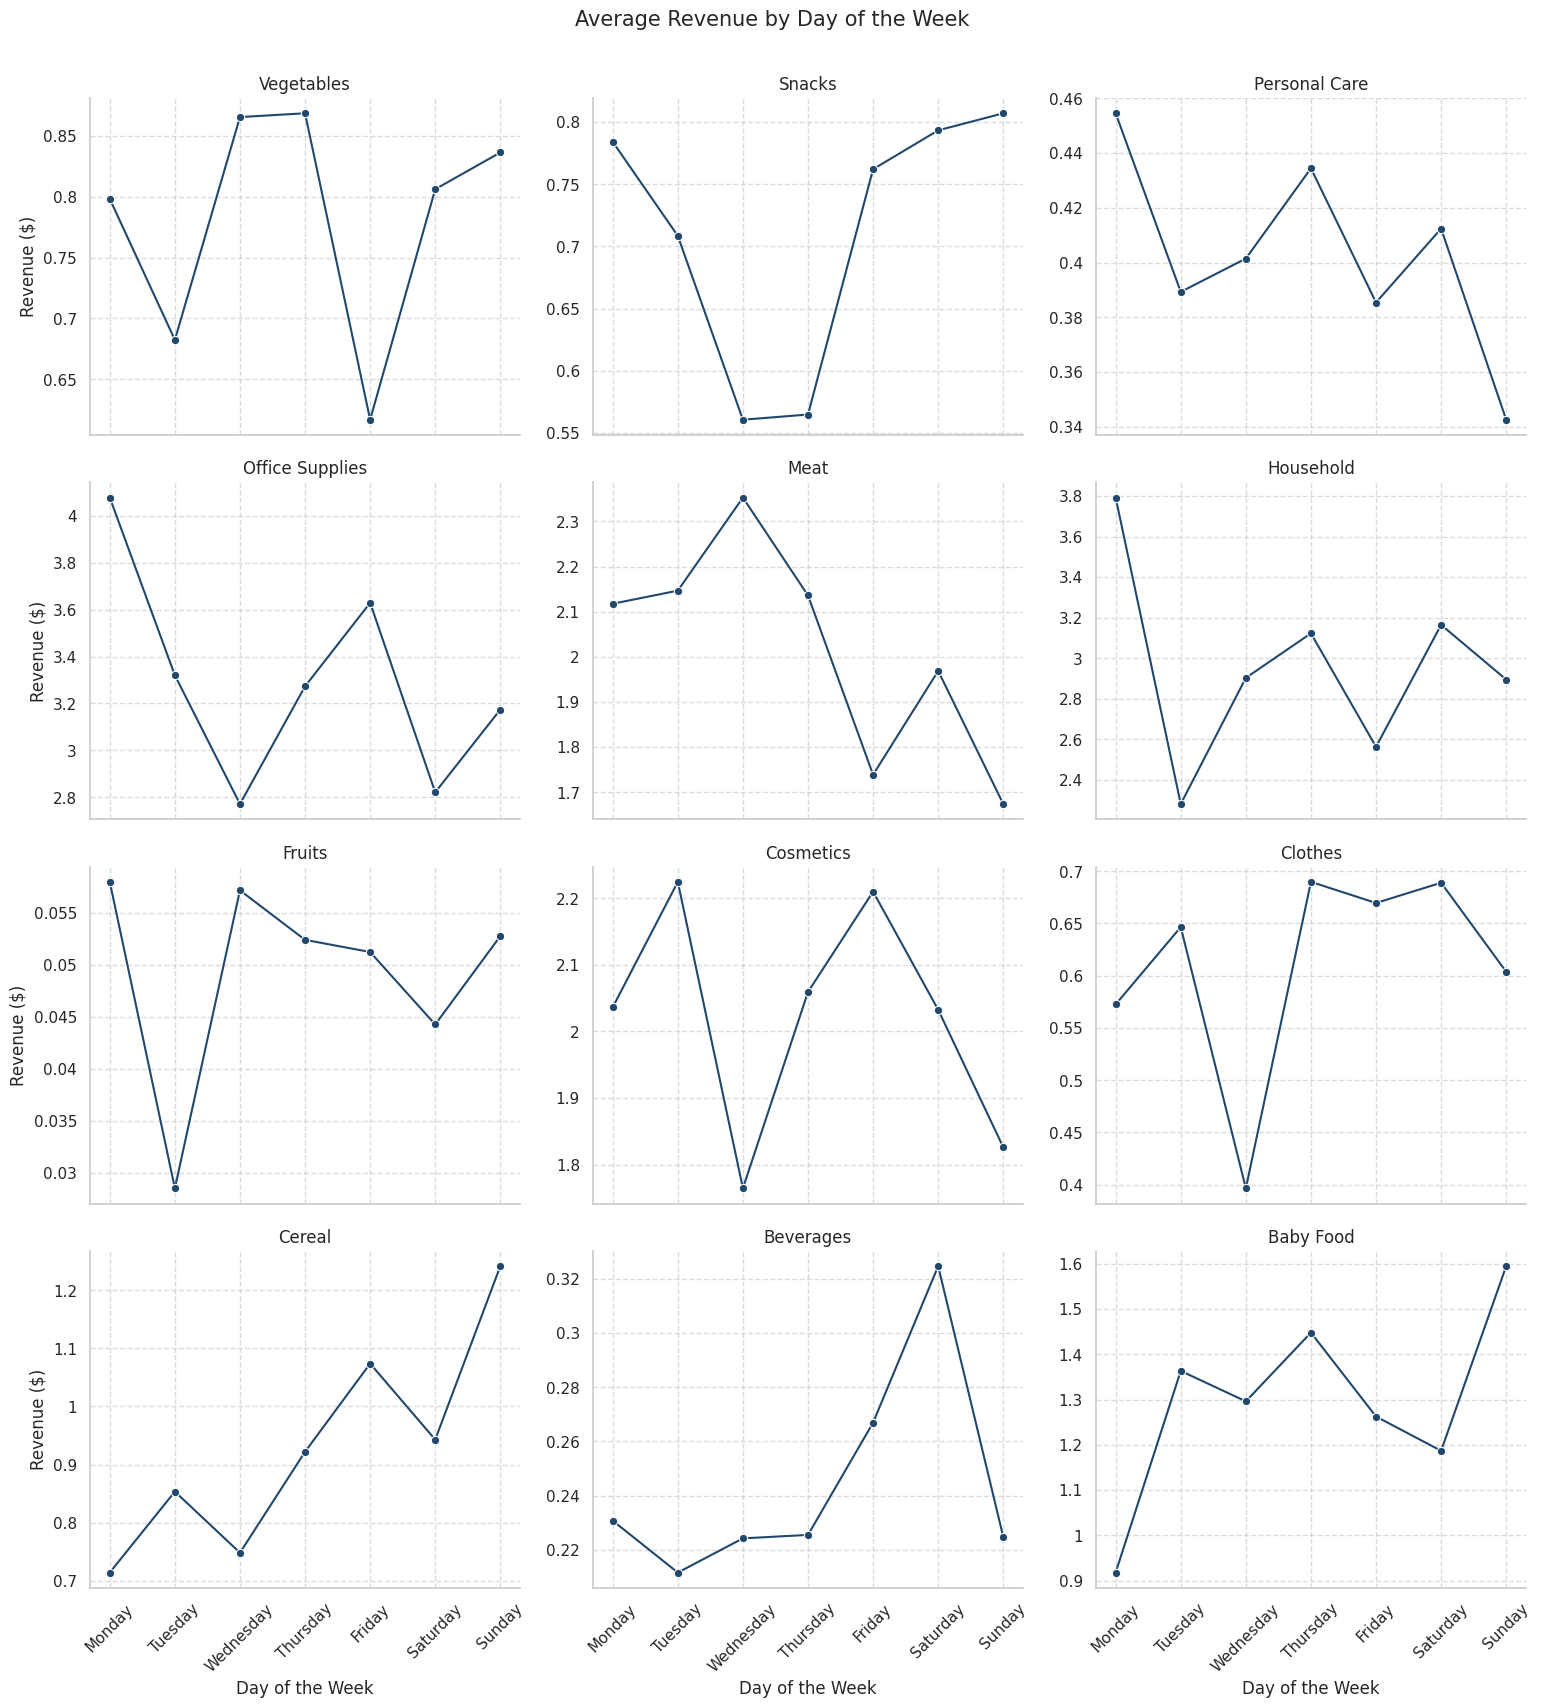

In [ ]:
df_final["day_of_week"] = df_final["order date"].dt.day_name()
weekday_sales = (df_final.groupby(["day_of_week", "product category"])["total revenue"].mean().reset_index())
weekday_sales["revenue_mln"] = weekday_sales["total revenue"] / 1_000_000
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
weekday_sales["day_of_week"] = pd.Categorical(weekday_sales["day_of_week"], categories=days_order, ordered=True)
weekday_sales = weekday_sales.sort_values("day_of_week")

g = sns.relplot(data=weekday_sales, x="day_of_week", y="revenue_mln", col="product category", col_wrap=3, kind="line", marker="o", color="#21486c", height=4, aspect=1.3, facet_kws={"sharey": False})

g.set_titles("{col_name}")
g.set_axis_labels("Day of the Week", "Revenue ($)")

for ax in g.axes.flat:
    ax.grid(axis="both", linestyle="--", alpha=0.7)
    ax.tick_params(axis="x", labelrotation=45)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%g"))
g.fig.suptitle("Average Revenue by Day of the Week", fontsize=15, y=1.03)
plt.show()

**Cosmetics:** Tuesday's peak is only \$2.22 million, and Wednesday's low is \$1.76 million.

**Fruits:** The entire chart is narrow corridor ranging from \$0.03 to \$0.058 million.

**Baby Food:** All fluctuations occur in the range from \$0.9 to \$1.6 million.

No category shows a significant drop on certain days, which would indicate that the product is not being purchased on these days.

Analyzing days of the week does not show seasonality, as it is measured in much larger cycles - months and seasons. Based on previous long-term charts (where we saw the dynamics for 2010 - 2017), the products in the portfolio can be clearly divided by seasonality:

**1. Products with pronounced seasonality**
Vegetables, Fruits, Clothes, Snacks: These four categories demonstrate a clear cyclical "boom-and-bust" pattern on a long-term chart. Sales regularly drop to baseline levels, after which there is a rapid recovery.

For Vegetables and Fruits, this is the classic seasonality of ripening and harvesting.

For Clothes, it is the seasonality of updating collections (spring/autumn) and preparing for changing weather.

**2. Event-driven products**
Office Supplies: Has sharp, impulsive spikes (\$1 million to \$15 million). This is seasonality, tied to corporate purchases — for example, fiscal year-end budget utilization by companies at the end of the fiscal year or preparation for the business season in the fall.

Cosmetics: Regular fluctuations, which are likely to be amplified during global holidays (New Year, Valentine's Day, etc.), when products are massively purchased for gifts.

**3. Non-seasonal products**
Baby Food & Personal Care: These categories are more predictable and stable throughout the year. Babies need food every day, and people use hygiene products regardless of the season, so the demand here forms a steady, uniform baseline.

**General Conclusions & Strategic Recommendations**

We can observe absolute dependence on the European market: The company is critically dependent on Europe, where annual sales are measured in hundreds of millions of dollars, peaking at ~\$250 million in 2012. Asia remains a tiny, albeit stable, niche market with figures reaching \$22 million.

Systemic Crisis (2015 - 2017): The main strategic risk is the progressive three-year decline in the European market. The reduction in European revenue to a historic low of ~\$120 million in 2017 triggered a synchronous decline in financial performance at all other levels of the business.

Switching to annual data allows us to clearly separate product categories by their financial roles:

Revenue drivers (high-yield): Categories such as Office Supplies (peaking at >\$75 million), Cosmetics, and Household form the basis of the company’s cash flow. However, Office Supplies has suffered a catastrophic decline since 2015, and the Meat category remains in a state of chronic annual decline.

Average stagnation (average revenue): The Baby Food and Cereal categories show deep, long-term stagnation, with sales volumes declining several times by 2017. Vegetables, Snacks, and Clothes are subject to cyclical fluctuations, but also synchronously sank towards the end of the study period.

Resilient microcategories (low revenue): Beverages was the only segment that barely reacted to the general crisis of 2017, maintaining a stable turnover in the range of \$3.8 - 4 million. Fruits, as expected, remains the smallest and most volatile segment of the company, remaining at less than \$1 million per year.

Analysis of sales at the level of individual countries with the highest indicators (Bosnia and Herzegovina, Andorra, and Ukraine) completely refutes the hypothesis of stable retail demand. The charts show a pronounced sawtooth pattern with massive spikes reaching \$14 - 20+ million, which indicates that the business is largely dependent on sporadic, large wholesale contracts rather than on consistently satisfying consumer needs.

The regression plot shows a weak but positive linear trend between order processing time and average profit. Longer order preparation and picking times (which can take up to 40 - 50 days) do not reduce margins; on the contrary, they are associated with larger and more profitable wholesale lots.

The company maintains excellent margins on large wholesale orders, where logistics take longer but bring high profits. Therefore, the main problem lies not in the operational plane, but rather in geomarketing and macro trends. A prolonged three-year recession in a key European market, combined with a collapse in sales in the leading Office Supplies category, requires immediate action: diversifying the business, expanding the company's presence in Asia, and revising marketing strategies to aggressively promote Cosmetics and Beverages as the most sustainable, crisis-resistant products.